In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import Analytic_t_dep_sim as ATDS

import A_nl_altered_sims as A_nl

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

import matplotlib.pyplot as plt

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [2]:

import importlib
importlib.reload(ATDS)


animate = False
SphHT = False
integrator = 'leapfrog'

sim = ATDS.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 10, no_time_steps = 1000, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [3]:
sim.run_simulation()

l max from jaxsp: 23
Total enclosed mass at rmax: 6.640e+02
Total mass from wavefunction: 7.164e+02
Scaling density and mass by factor 1.0789847457919062 to match total mass
Particle 0: v_circ = 3.404 km/s
Particle 1: v_circ = 3.070 km/s
Particle 2: v_circ = 3.409 km/s
Particle 3: v_circ = 3.847 km/s
Particle 4: v_circ = 3.138 km/s
Particle 5: v_circ = 3.590 km/s
Particle 6: v_circ = 3.487 km/s
Particle 7: v_circ = 3.815 km/s
Particle 8: v_circ = 3.930 km/s
Particle 9: v_circ = 3.611 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...


W0417 11:16:20.349452 3718085 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.52GiB (rounded to 8069936384)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0417 11:16:20.350080 3718085 bfc_allocator.cc:513] **********___________*******________________________________________________________________________
E0417 11:16:20.350115 3718085 pjrt_stream_executor_client.cc:2091] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 7.52GiB. [tf-allocator-allocation-error='']


KeyboardInterrupt: 

In [9]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in sim.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(10, 1001, 3)


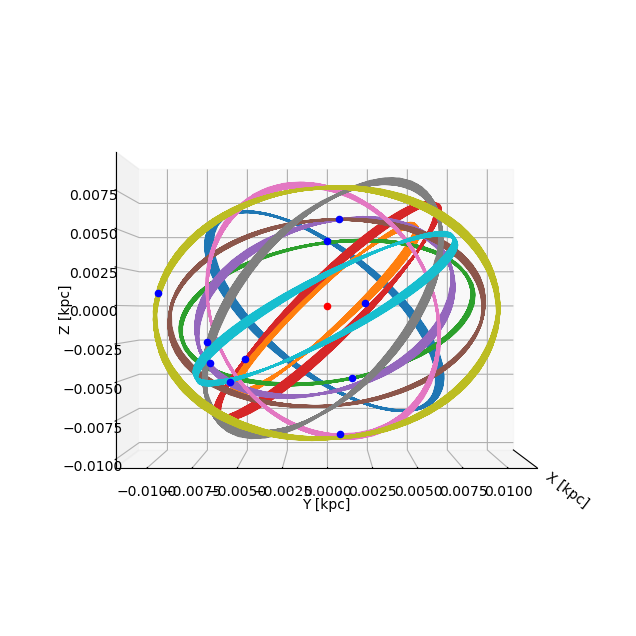

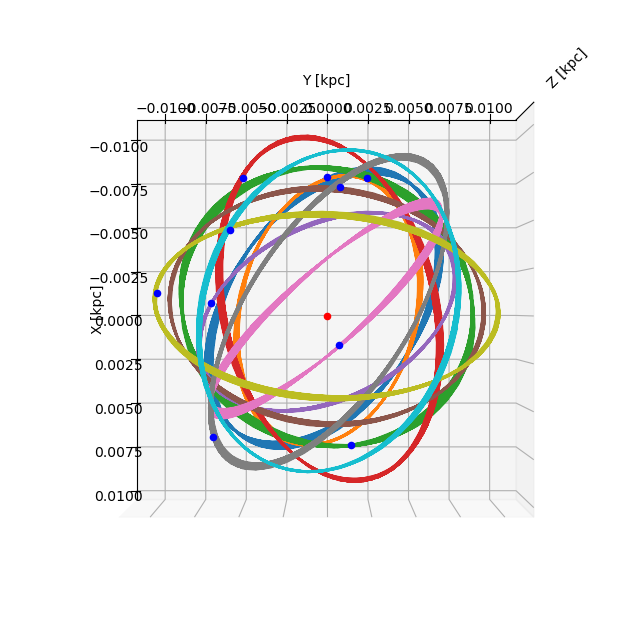

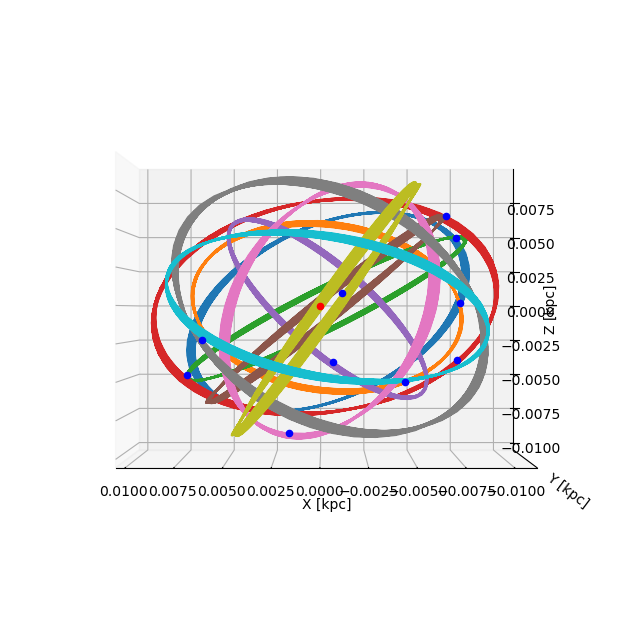

In [10]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


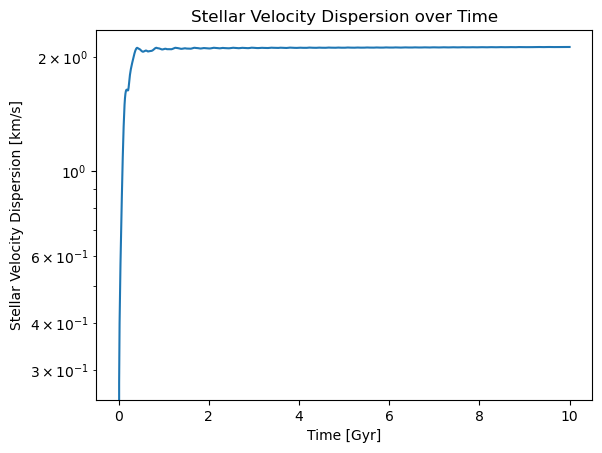

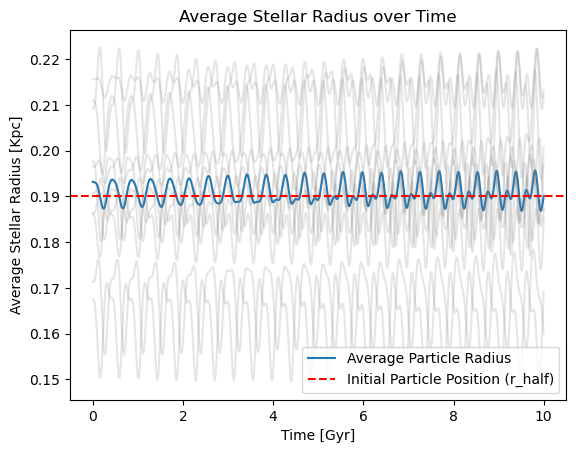

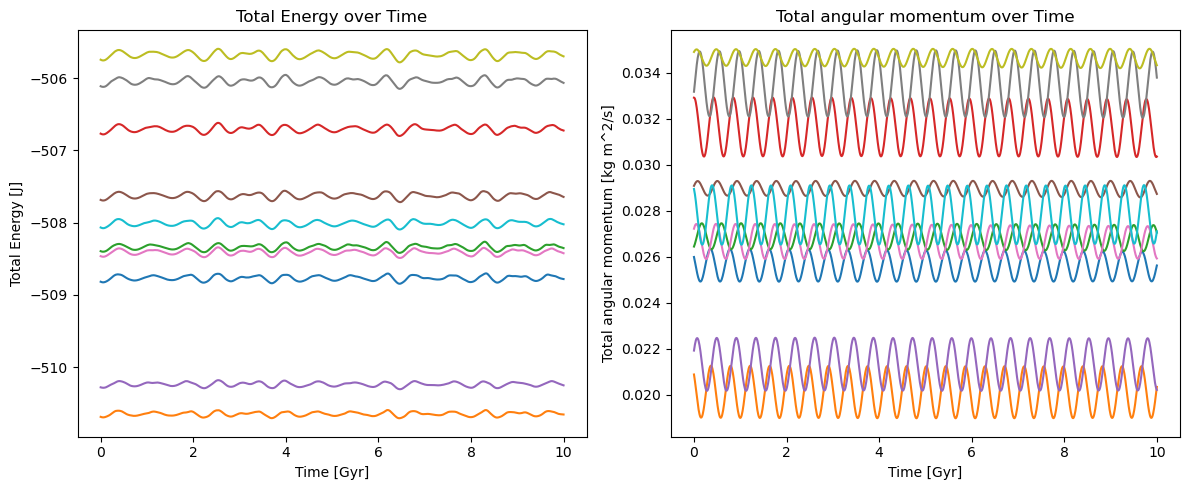

In [11]:
time_step2 = sim.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, average_r2 * sim.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[particle] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()




# Altering the original $a_{nl}$ coefficients so states with larger (n,l) have higher $a_{nl}$

In [2]:

import importlib
importlib.reload(A_nl)

animate = False
SphHT = False
integrator = 'leapfrog'
a_nl_range = 'orbital'
plot = True

sim = A_nl.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 5, no_time_steps = 500, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, a_nl_range= a_nl_range, plot = plot, boost_factor=1e15, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


l max from jaxsp: 23


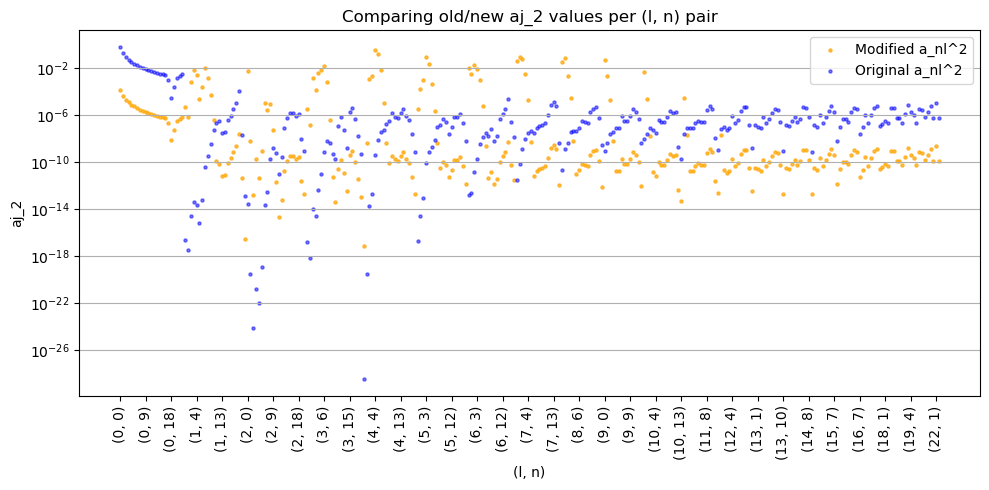

Total enclosed mass at rmax: 6.172e+03
Total mass from wavefunction: 7.164e+02
Scaling density and mass by factor 0.11607846677314382 to match total mass


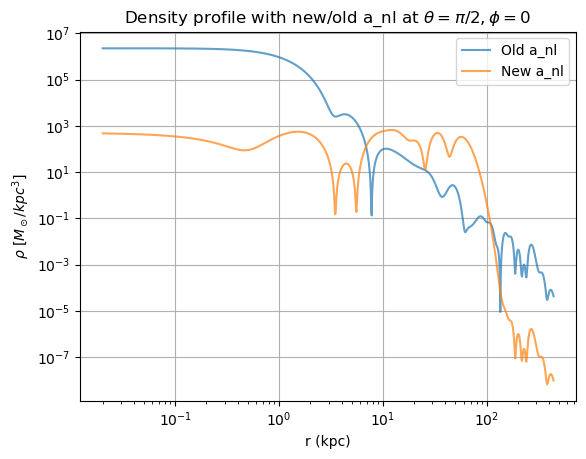

Particle 0: v_circ = 0.018 km/s
Particle 1: v_circ = 0.016 km/s
Particle 2: v_circ = 0.018 km/s
Particle 3: v_circ = 0.020 km/s
Particle 4: v_circ = 0.016 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...
Time step 1 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 1.12 seconds
Time step 2 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.82 seconds
Time step 3 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.79 seconds
Time step 4 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.69 seconds
Time step 5 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.91 seconds
Time step 6 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.91 seconds
Time step 7 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.84 seconds
Time step 8 / 500
  Force calls this timestep: 1
Time stepping all

In [3]:
sim.run_simulation()

In [4]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in sim.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(5, 501, 3)


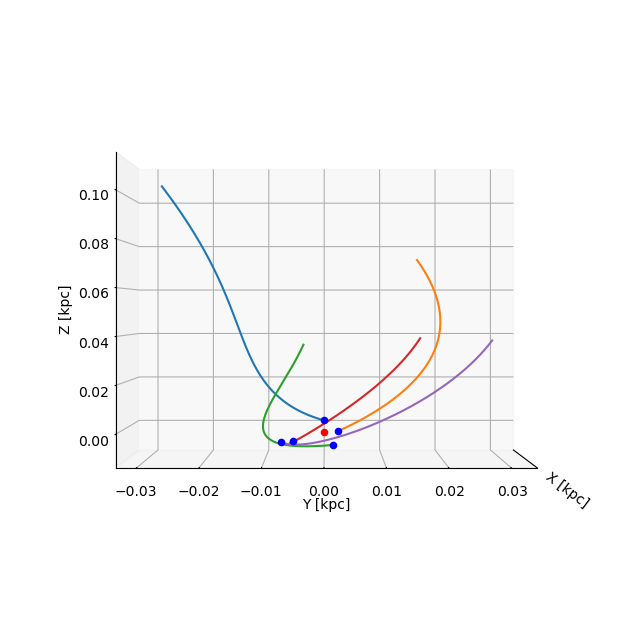

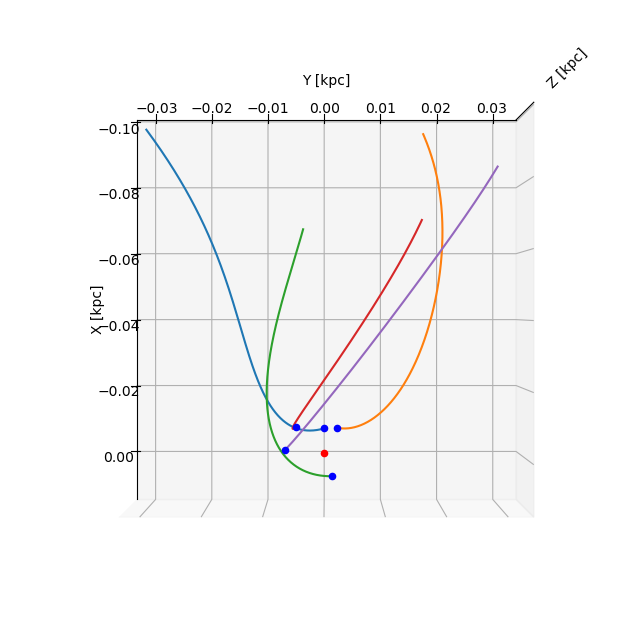

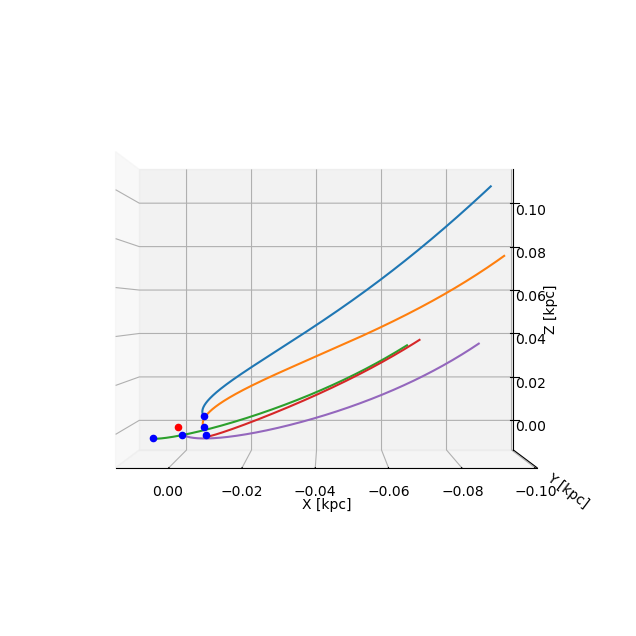

In [5]:
print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


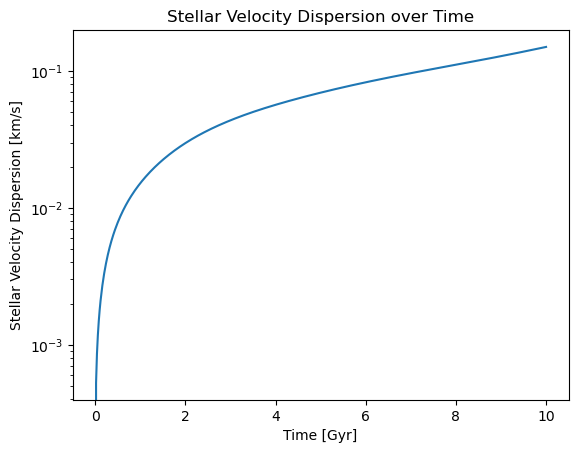

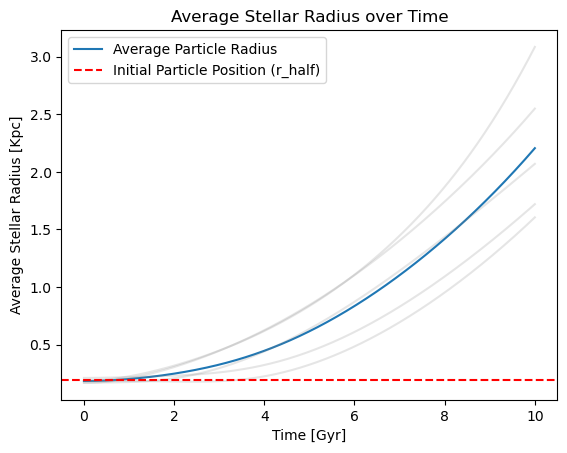

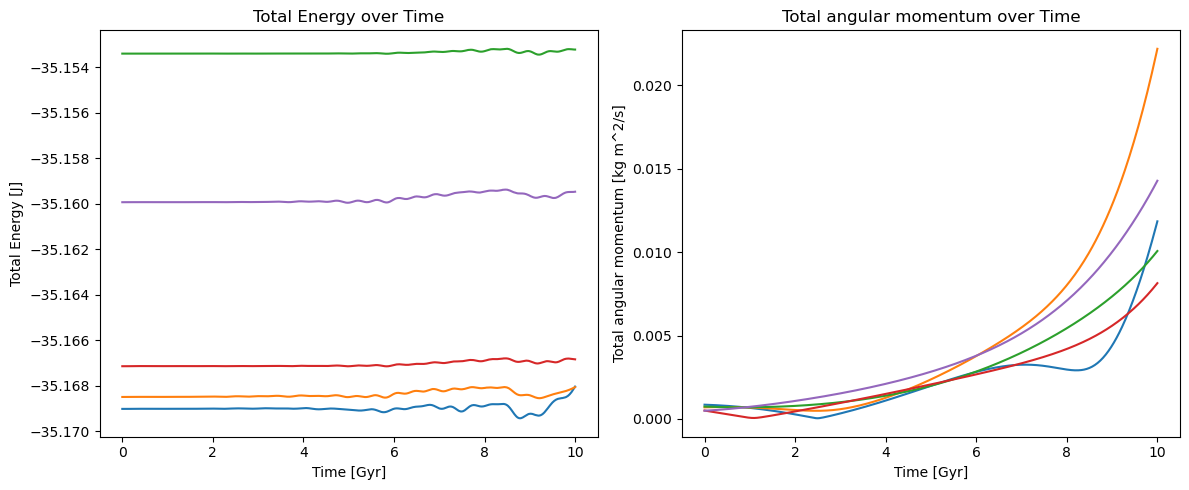

In [6]:
time_step2 = sim.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, average_r2 * sim.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[particle] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()
